In [1]:
import pandas as pd 
import numpy as np 

In [2]:
df=pd.read_csv('lung_cancer_multimodal_papers.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248 entries, 0 to 247
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   source                 248 non-null    object 
 1   title                  248 non-null    object 
 2   authors                248 non-null    object 
 3   year                   248 non-null    int64  
 4   venue                  248 non-null    object 
 5   abstract               247 non-null    object 
 6   doi                    247 non-null    object 
 7   url                    248 non-null    object 
 8   query_used             248 non-null    object 
 9   fusion_keywords_found  248 non-null    object 
 10  modalities_found_auto  248 non-null    object 
 11  multimodal_score       248 non-null    int64  
 12  priority               248 non-null    object 
 13  screen_flag            248 non-null    object 
 14  exclusion_hint         33 non-null     object 
 15  includ

C:\Users\MatenTech\AppData\Local\Temp\ipykernel_22816\499640382.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=year_counts.index.astype(int), y=year_counts.values, palette="Blues_d")
C:\Users\MatenTech\AppData\Local\Temp\ipykernel_22816\499640382.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mod_counts.values, y=mod_counts.index, palette="rocket")


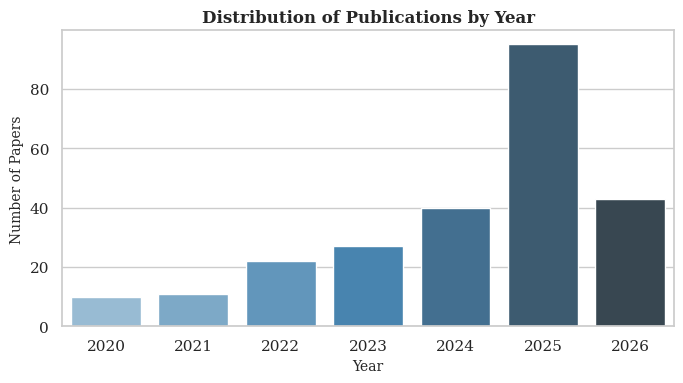

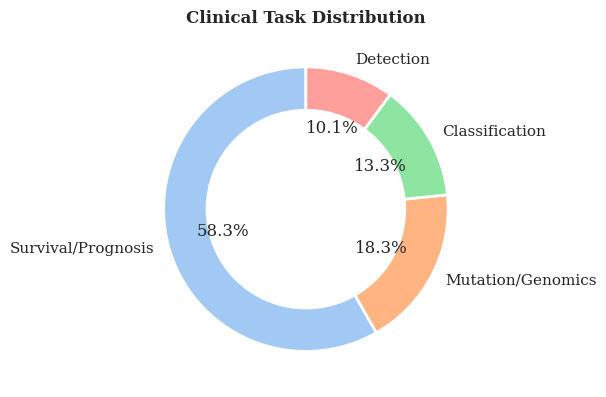

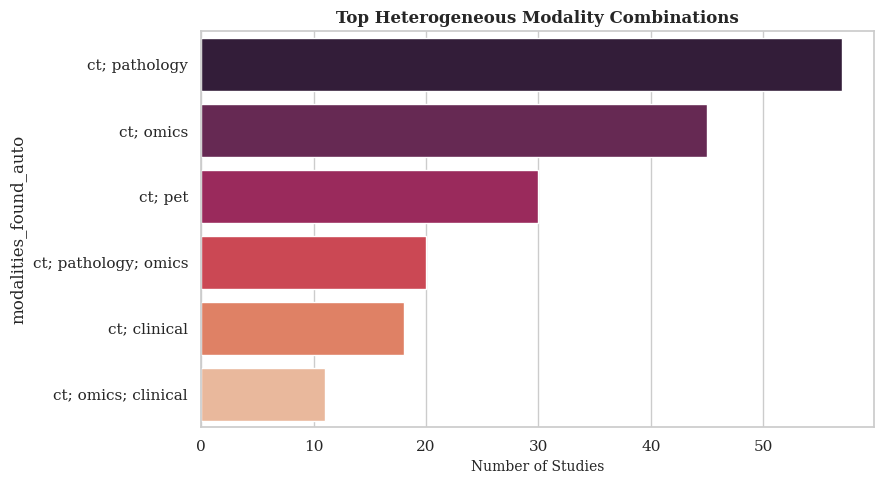

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional theme
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'serif'

# Load your CSV
df = pd.read_csv('lung_cancer_multimodal_papers.csv')

# --- Fig 1: Yearly Growth (Bar) ---
plt.figure(figsize=(7, 4))
year_counts = df['year'].value_counts().sort_index()
sns.barplot(x=year_counts.index.astype(int), y=year_counts.values, palette="Blues_d")
plt.title('Distribution of Publications by Year', fontsize=12, fontweight='bold')
plt.xlabel('Year', fontsize=10)
plt.ylabel('Number of Papers', fontsize=10)
plt.tight_layout()
plt.savefig('styled_year_dist.png', dpi=300)

# --- Fig 2: Research Tasks (Donut Chart) ---
plt.figure(figsize=(6, 6))
# Using counts from the analysis: Survival (127), Mutation (40), Classification (29), etc.
task_counts = [127, 40, 29, 22]
labels = ['Survival/Prognosis', 'Mutation/Genomics', 'Classification', 'Detection']
colors = sns.color_palette("pastel")[0:4]
plt.pie(task_counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors, 
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
# Transform into a Donut (Standard in modern reviews)
centre_circle = plt.Circle((0,0), 0.70, fc='white')
plt.gcf().gca().add_artist(centre_circle)
plt.title('Clinical Task Distribution', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('styled_task_donut.png', dpi=300)

# --- Fig 3: Modality Combinations (Horizontal) ---
plt.figure(figsize=(9, 5))
# Preprocessing modalities to be clean (e.g., CT + PET)
mod_counts = df['modalities_found_auto'].value_counts().head(6)
sns.barplot(x=mod_counts.values, y=mod_counts.index, palette="rocket")
plt.title('Top Heterogeneous Modality Combinations', fontsize=12, fontweight='bold')
plt.xlabel('Number of Studies', fontsize=10)
plt.tight_layout()
plt.savefig('styled_modality_bar.png', dpi=300)

In [6]:
df=pd.read_csv('After_Review- lung_cancer_multimodal_papers.csv')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248 entries, 0 to 247
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   source                 248 non-null    object 
 1   title                  248 non-null    object 
 2   authors                248 non-null    object 
 3   year                   248 non-null    int64  
 4   venue                  248 non-null    object 
 5   abstract               247 non-null    object 
 6   doi                    247 non-null    object 
 7   url                    248 non-null    object 
 8   query_used             248 non-null    object 
 9   fusion_keywords_found  248 non-null    object 
 10  modalities_found_auto  248 non-null    object 
 11  multimodal_score       248 non-null    int64  
 12  priority               248 non-null    object 
 13  screen_flag            248 non-null    object 
 14  exclusion_hint         33 non-null     object 
 15  includ

In [9]:
task=df['Task'].value_counts()

In [10]:
task[0:20]

Task
EGFR Mutation Prediction                    4
Benign vs. Malignant Classification         2
Risk Prediction / Early Detection           1
Subtyping (LUAD vs LUSC)                    1
Differential Diagnosis (BA vs LUAD)         1
TKI Resistance Prediction                   1
DFS Prediction (Recurrence)                 1
Prognosis (Survival)                        1
Real-time Tumor Tracking                    1
OLM Prediction (Metastasis)                 1
Nodule Detection + Mortality Prediction     1
Drug Synergy Prediction                     1
Multi-task: Nodule Detection to Survival    1
5-Year Survival Prediction                  1
Subtype Classification & TNM Staging        1
LASSO + Nomogram + ResNet-34                1
Differential Diagnosis                      1
5-Year Survival/Prognosis                   1
EGFR & KRAS Mutation Prediction             1
Quantitative OS Prediction                  1
Name: count, dtype: int64

In [11]:
df['notes'].value_counts()

notes
1.0    22
0.0     8
Name: count, dtype: int64

In [13]:
transformers_multimodal=df[df['notes']==1.0]

In [14]:
transformers_multimodal.to_csv('transformers_multimodal.csv', index=False)

In [15]:
transformers_multimodal

,source,title,authors,year,venue,abstract,doi,url,query_used,fusion_keywords_found,...,exclude_reason_final,notes,Modalities,Architecture,Task,Fusion Type,Transformer,Dataset,Key Metric,Reaserch Gap
2,PubMed,Cross-attention multimodal fusion for EGFR mut...,Yuanshun Jiang; Bao Feng; Yehang Chen; Junhui ...,2026,Medical physics,BACKGROUND: The prediction of Epidermal Growth...,10.1002/mp.70450,https://pubmed.ncbi.nlm.nih.gov/42050780/,"(""lung cancer"" OR ""lung neoplasm"" OR ""non-smal...",multimodal; fusion; cross-modal; cross-attention,...,NaN,1.0,CT (Macroscopic) + WSI (Microscopic),MFCA (Dual-Branch Encoder),EGFR Mutation Prediction,Joint (Cross-Attention),1.0,Internal Hospital Dataset (CT & WSI Pairs),AUC: 0.805 (Stromal),NaN
4,PubMed,A transformer-based patient-agnostic tumor mot...,Maidina Abuduxiku; Ningning Chai; Xiaoyan An; ...,2026,Medical physics,BACKGROUND: Accurate and real-time localizatio...,10.1002/mp.70449,https://pubmed.ncbi.nlm.nih.gov/42027140/,"(""lung cancer"" OR ""lung neoplasm"" OR ""non-smal...",cross-attention,...,NaN,1.0,DRR (Simulated X-ray) + Vision Camera,Transformer (Self/Cross-Attn),Real-time Tumor Tracking,Hubrid Joint fusion/Spatiotemporal Fusion,1.0,4DCT (25 pts) + 20 Volunteers,MAD: 0.07–0.29mm,NaN
5,PubMed,Predicting primary resistance to third-generat...,Yunfan Wang; Ke Min; Li Tao; Jun Jin; Lingling...,2026,NPJ precision oncology,The aim of this study was to investigate the u...,10.1038/s41698-026-01420-2,https://pubmed.ncbi.nlm.nih.gov/41998101/,"(""lung cancer"" OR ""lung neoplasm"" OR ""non-smal...",multimodal; cross-modal,...,NaN,1.0,CT Imaging + Clinical Tabular,Swin-T + Table-T,TKI Resistance Prediction,Joint (Cross-Modal),1.0,3 Cohorts (n=222),AUC: 0.89,The findings from MC-Trans \cite{mctrans2026} ...
6,PubMed,A multimodal radiomics model to predict diseas...,Weiming Zhao; Tingting Li; Xilong Zhou; Wenjin...,2026,Journal of thoracic disease,BACKGROUND: Predicting disease-free survival (...,10.1007/s10278-025-01748-4,https://pubmed.ncbi.nlm.nih.gov/41419702/,"(""lung cancer"" OR ""lung neoplasm"" OR ""non-smal...",multimodal; fusion,...,NaN,1.0,DECT + Clinical + Radiomics + Deep Features,ExtraTrees / 3D-DenseNet,DFS Prediction (Recurrence),Feature-Level (Pre-fusion),0.0,Single Center (n=171),AUC: 0.889,Studies like Zheng et al. (2026) highlight a r...
8,PubMed,Lightweight hybrid foundation model for lung c...,Helen Haile Hayeso; Zenebe Markos Lonseko; Fah...,2026,Translational lung cancer research,BACKGROUND: Lung cancer (LC) is the leading ca...,10.1038/s41598-019-53461-2,https://pubmed.ncbi.nlm.nih.gov/31754135/,"(""lung cancer"" OR ""lung neoplasm"" OR ""non-smal...",multimodal,...,NaN,1.0,CXR (X-ray) + BioGPT Prompts + Metadata,SAM-Med2D + BioGPT,Prognosis (Survival),Joint,1.0,"JSRT, PadChest, NIH",C-index: 0.910,Most high-performance multimodal models requir...
9,PubMed,LANTERN-XGB: An Interpretable Multi-Modal Mach...,Davide Dalfovo; Carolina Sassorossi; Elisa De ...,2026,International journal of molecular sciences,Non-small cell lung cancer (NSCLC) remains the...,10.1073/pnas.0506580102,https://pubmed.ncbi.nlm.nih.gov/16199517/,"(""lung cancer"" OR ""lung neoplasm"" OR ""non-smal...",multi-modal,...,NaN,1.0,CT + PET + Clinical + Transcriptomics,XGBoost (Tree Boosting),OLM Prediction (Metastasis),Hierarchical Fusion,0.0,3 Cohorts (n=637),AUC: 0.77 (Ext. Val),"While Transformer-based models (e.g., Jiang et..."
10,PubMed,Multimodal Deep Learning for Pulmonary Nodule ...,Junxian Li; Yuchen Xing; Ximin Gao; Ya Liu; Li...,2026,MedComm,Chest radiographs (CXRs) may encode prognostic...,10.1002/mco2.70730,https://pubmed.ncbi.nlm.nih.gov/17244633/,"(""lung cancer"" OR ""lung neoplasm"" OR ""non-smal...",multimodal; multimodal deep learning,...,NaN,1.0,CXR + 4 Epidemiologic Variables,Multimodal DL Encoder,Nodule Detection + Mortality Prediction,Feature Fusion (Joint),1.0,"PLCO, TLCID (n > 30k)",AUC: 0.979 (Nodule),NaN
11,PubMed,Graphicalized vision-language modeling for com...,Danwen 

In [16]:
non_transformers_multimodal=df[df['notes']==0.0]

In [18]:
non_transformers_multimodal

,source,title,authors,year,venue,abstract,doi,url,query_used,fusion_keywords_found,...,exclude_reason_final,notes,Modalities,Architecture,Task,Fusion Type,Transformer,Dataset,Key Metric,Reaserch Gap
0,PubMed,An exploratory study of multi-channel CNN for ...,Chia-Hui Chien; Shih-Chuan Chang; Yung-Chun Ch...,2026,Scientific reports,Lung cancer remains the leading cause of cance...,10.1038/s41598-026-52173-8,https://pubmed.ncbi.nlm.nih.gov/42115281/,"(""lung cancer"" OR ""lung neoplasm"" OR ""non-smal...",multi-modal,...,NaN,0.0,Clinical / Claims Only,Multi-Channel CNN (MCNN),Risk Prediction / Early Detection,Early Fusion,0.0,NHIRD (National Health Insurance Research Data...,NaN,NaN
1,PubMed,A fusion model based on tumor and peritumoral ...,Ziqian Zhao; Tengfei Ke; Zeyan Xu; Yong Zhou; ...,2026,Frontiers in oncology,PURPOSE: This study aimed to develop and valid...,10.21037/qims-2024-2836,https://pubmed.ncbi.nlm.nih.gov/41081208/,"(""lung cancer"" OR ""lung neoplasm"" OR ""non-smal...",fusion,...,NaN,0.0,CT (Tumor + Peritumoral) + Clinical,MLP (Multi-Layer Perceptron),Differential Diagnosis (BA vs LUAD),Late / Feature Fusion,0.0,"Medical Center 1 (Internal Cohort, n=281)",NaN,NaN
3,PubMed,Deep feature optimization using fusion of mult...,Nepolian Vailankanni; Bharanidharan Nagarajan,2026,PloS one,One of the most deadly illnesses in the world ...,10.1148/radiol.232057,https://pubmed.ncbi.nlm.nih.gov/38591974/,"(""lung cancer"" OR ""lung neoplasm"" OR ""non-smal...",fusion,...,NaN,0.0,Histopathology (WSI),Vision GNN (ViG),Subtyping (LUAD vs LUSC),Unimodal Multi-Feature,0.0,"LC25000, TCGA, LungHist700",Accuracy: 97%,NaN
12,PubMed,A scalable multimodal graph neural network for...,Dhekra Saeed; Huanlai Xing; Li Feng,2026,Molecular diversity,Background Resistance to targeted cancer thera...,10.1016/j.ins.2009.12.010,https://pubmed.ncbi.nlm.nih.gov/38340091/,"(""lung cancer"" OR ""lung neoplasm"" OR ""non-smal...",multimodal,...,NaN,0.0,Molecular Fingerprints + SMILES (Graph),Heterophily-aware GNN,Drug Synergy Prediction,Multimodal Feature Fusion,0.0,"DrugComb, NCI-ALMANAC",MSE: 16.18,NaN
13,PubMed,Multimodal AI for pneumonia and lung cancer cl...,Chauhan Pradip; Chauhan Girish; Chauhan Bhoomi...,2026,Bioinformation,Chest X-ray and HRCT are essential for diagnos...,10.6026/973206300220605,https://pubmed.ncbi.nlm.nih.gov/28732268/,"(""lung cancer"" OR ""lung neoplasm"" OR ""non-smal...",multimodal; fusion,...,NaN,0.0,CXR (X-ray) + HRCT,ResNet-50 + DenseNet-121,Differential Diagnosis,Late Fusion (Decision),0.0,Public (ChestX-ray14 + LIDC),Accuracy: 94.6%,While models like DeepScan (2026) show that co...
16,PubMed,Grad-CAM Enhanced Explainable Deep Learning fo...,Murat Kılıç; Merve Bıyıklı; Abdulkadir Yelman;...,2026,"Diagnostics (Basel, Switzerland)",Background/Objectives: Lung cancer (LC) is the...,10.1016/j.patcog.2024.110657,https://pubmed.ncbi.nlm.nih.gov/38685985/,"(""lung cancer"" OR ""lung neoplasm"" OR ""non-smal...",fusion,...,NaN,0.0,Unimodal,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19,PubMed,Enhanced CT-based deep learning radiomics and ...,Jianbin Zhu; Huaxian Shi; Zhuofeng Liang; Ting...,2026,Translational cancer research,BACKGROUND: Identifying predictive markers for...,10.1007/s00262-024-03724-3,https://pubmed.ncbi.nlm.nih.gov/38833187/,"(""lung cancer"" OR ""lung neoplasm"" OR ""non-smal...",fusion,...,NaN,0.0,Enhanced CT + Radiomics + DL (ResNet-34) + Cli...,LASSO + Nomogram + ResNet-34,LASSO + Nomogram + ResNet-34,Hybrid Fusion (Nomogram),0.0,Internal (201 patients) + TCIA,AUC: 0.894 (Test),NaN
22,PubMed,Inferring tumor immune microenvironment -relat...,Lei Yuan; Qi Wang; Fei Sun; Wenlong Yang; Jie ...,2026,Frontiers in immunology,BACKGROUND: Checkpoint inhibitor pneumonitis (...,10.1038/s41698-025-00939-0,https://pubmed.ncbi.nlm.nih.gov/40467921/,"(""lung cancer"" OR ""lung neoplasm"" OR ""non-smal...",multimodal; fusion; cross-modal,...,NaN,0.0,H&E Slides (WSI) + Clinical Variables,CNN + Multi-Instance Learning (MIL),Adverse Event 

In [19]:
non_transformers_multimodal.to_csv('non_transformers_multimodal.csv', index=False)